# Challenge: Backtest on Other Datasets

## Download data from `yfinance`

In [1]:
import sys
sys.executable

'c:\\Users\\thelm\\AppData\\Local\\Programs\\Python\\Python313\\python.exe'

In [2]:
import yfinance as yf

In [3]:
##yf.download??

In [4]:
ticker = 'PLTR'
palantir_df = yf.download(tickers=ticker, multi_level_index=False)
palantir_df

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2020-09-30,9.500000,11.410000,9.110000,10.000000,338584400
2020-10-01,9.460000,10.100000,9.230000,9.690000,124297600
2020-10-02,9.200000,9.280000,8.940000,9.060000,55018300
2020-10-05,9.030000,9.490000,8.920000,9.430000,36316900
2020-10-06,9.900000,10.180000,8.900000,9.040000,90864000
...,...,...,...,...,...
2025-05-20,125.589996,128.199997,124.650002,127.220001,61265300
2025-05-21,120.580002,127.110001,119.410004,125.160004,80657700
2025-05-22,122.290001,126.330002,121.375000,121.949997,75498300


In [5]:
##palantir_df.drop??

In [6]:
#get rid of the ticker row 
palantir_df.shape

(1169, 5)

## Preprocess the data

### Filter the date range

- Since 1 year ago at least

In [7]:
palantir_df

,Close,High,Low,Open,Volume
Date,,,,,
2020-09-30,9.500000,11.410000,9.110000,10.000000,338584400
2020-10-01,9.460000,10.100000,9.230000,9.690000,124297600
2020-10-02,9.200000,9.280000,8.940000,9.060000,55018300
2020-10-05,9.030000,9.490000,8.920000,9.430000,36316900
2020-10-06,9.900000,10.180000,8.900000,9.040000,90864000
...,...,...,...,...,...
2025-05-20,125.589996,128.199997,124.650002,127.220001,61265300
2025-05-21,120.580002,127.110001,119.410004,125.160004,80657700
2025-05-22,122.290001,126.330002,121.375000,121.949997,75498300


In [8]:
excluding_covid_palantir_df = palantir_df.loc['2022-01-01': ].copy()
excluding_covid_palantir_df

,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,18.530001,18.569000,17.860001,18.360001,34283600
2022-01-04,18.170000,18.840000,17.790001,18.610001,39643200
2022-01-05,16.959999,18.568001,16.870001,18.030001,58445900
2022-01-06,16.740000,17.180000,16.055000,16.870001,49737100
2022-01-07,16.559999,17.330000,16.475000,16.700001,37989300
...,...,...,...,...,...
2025-05-20,125.589996,128.199997,124.650002,127.220001,61265300
2025-05-21,120.580002,127.110001,119.410004,125.160004,80657700
2025-05-22,122.290001,126.330002,121.375000,121.949997,75498300


### Create the target variable

#### Percentage change

- Percentage change on `Adj Close` for tomorrow

In [9]:
excluding_covid_palantir_df['change_tomorrow'] = excluding_covid_palantir_df.Close.pct_change(-1) * 100 * -1

#### Drop rows with any missing data

In [10]:
excluding_covid_palantir_df = excluding_covid_palantir_df.dropna().copy()
excluding_covid_palantir_df

,Close,High,Low,Open,Volume,change_tomorrow
Date,,,,,,
2022-01-03,18.530001,18.569000,17.860001,18.360001,34283600,-1.981291
2022-01-04,18.170000,18.840000,17.790001,18.610001,39643200,-7.134440
2022-01-05,16.959999,18.568001,16.870001,18.030001,58445900,-1.314213
2022-01-06,16.740000,17.180000,16.055000,16.870001,49737100,-1.086958
2022-01-07,16.559999,17.330000,16.475000,16.700001,37989300,-0.363633
...,...,...,...,...,...,...
2025-05-19,126.330002,127.769997,124.320000,124.714996,72503900,-0.589223
2025-05-20,125.589996,128.199997,124.650002,127.220001,61265300,-4.154913
2025-05-21,120.580002,127.110001,119.410004,125.160004,80657700,1.398315


<Axes: >

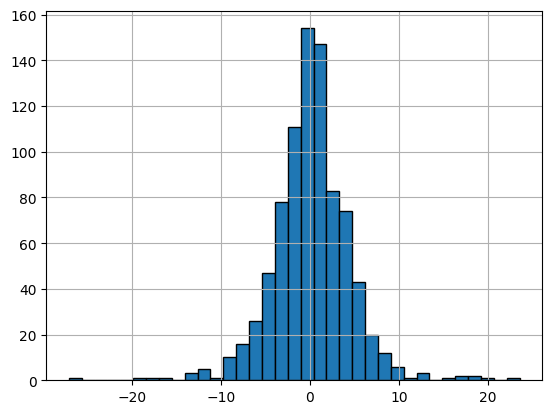

In [11]:
excluding_covid_palantir_df.change_tomorrow.hist(bins=35, edgecolor='black')

In [18]:
excluding_covid_palantir_df.change_tomorrow.std()

np.float64(4.393444627014472)

#### Change sign

Did the stock go up or down?

In [19]:
import numpy as np 

excluding_covid_palantir_df['change_tomorrow_direction'] = np.where(excluding_covid_palantir_df.change_tomorrow > 0, 1, -1)
excluding_covid_palantir_df

,Close,High,Low,Open,Volume,change_tomorrow,change_tomorrow_direction
Date,,,,,,,
2022-01-03,18.530001,18.569000,17.860001,18.360001,34283600,-1.981291,-1
2022-01-04,18.170000,18.840000,17.790001,18.610001,39643200,-7.134440,-1
2022-01-05,16.959999,18.568001,16.870001,18.030001,58445900,-1.314213,-1
2022-01-06,16.740000,17.180000,16.055000,16.870001,49737100,-1.086958,-1
2022-01-07,16.559999,17.330000,16.475000,16.700001,37989300,-0.363633,-1
...,...,...,...,...,...,...,...
2025-05-19,126.330002,127.769997,124.320000,124.714996,72503900,-0.589223,-1
2025-05-20,125.589996,128.199997,124.650002,127.220001,61265300,-4.154913,-1
2025-05-21,120.580002,127.110001,119.410004,125.160004,80657700,1.398315,1


## Compute Machine Learning model

Proposal: Random Forest within `ensemble` module of `sklearn` library

In [14]:
from sklearn.ensemble import RandomForestClassifier

In [15]:
rf = RandomForestClassifier()

In [16]:
RandomForestClassifier??

Init signature:
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Source:        
class RandomForestClassifier(ForestClassifier):
    """
    A random forest classifier.

    A random forest is a meta estimator that fits a number of decision tree
    classifiers on various sub-samples of the dataset and uses averaging to
    improve the predictive accuracy and control over-fitting.
    Trees in the forest use the best split strategy, i.e. equivalent to passing
    `splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
    The sub-sample size is cont

In [17]:
rf.fit(exluding)

NameError: name 'exluding' is not defined

## Backtesting

### Create the Strategy

In [ ]:
from backtesting import Backtest, Strategy 

### Run the Backtest

In [ ]:
bt = Backtest(
    ???, ???, cash=10000,
    commission=.002, exclusive_orders=True
)

### Show the report in a DataFrame

## Plot the backtest report

> Don't worry about this new tool just yet, we will explain in a future chapter how to interpret the following chart.

In [ ]:
bt.plot(filename='palantir_backtest.html')

## How to invest based on the numerical increase?

> Instead of the direction (UP or DOWN)

Next chapter → [Backtesting with Regression Models]()

Classification Model | Regression Model
-|-
![](src/pred_classification.png) | ![](src/pred_regression.png)

Classification Strategy | Regression Strategy
-|-
![](src/res_classification.png) | ![](src/res_regression.png)